# GEFCom2014 数据提取与合并

**输入**: `GEFCom2014 Data.zip`（需放在 `config/` 同级目录或指定路径）

**处理流程**:
1. 从 L 赛道（负荷预测）提取：系统负荷 + 25站温度
2. 从 P 赛道（电价预测）提取：区域电价
3. 时间解析与对齐
4. 合并保存为 `pjm_merged_data.csv`

In [1]:
import zipfile
import pandas as pd
import numpy as np
from datetime import datetime
from pathlib import Path

# ========== 配置 ==========
ZIP_PATH = Path("D:/deeplearning/loadforcast/config/GEFCom2014 Data.zip")
OUTPUT_DIR = Path("D:/deeplearning/loadforcast/config")
OUTPUT_CSV = OUTPUT_DIR / "pjm_merged_data.csv"

assert ZIP_PATH.exists(), f"找不到 ZIP 文件: {ZIP_PATH}"
print(f"✓ ZIP 文件存在: {ZIP_PATH}")
print(f"  输出目录: {OUTPUT_DIR}")

✓ ZIP 文件存在: D:\deeplearning\loadforcast\config\GEFCom2014 Data.zip
  输出目录: D:\deeplearning\loadforcast\config


## Step 1: 探索 L 赛道时间格式

In [2]:
# 先读取 L 赛道 Task 15 的前 20 行，观察时间格式
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    with z.open('GEFCom2014 Data/GEFCom2014-L_V2/Load/Task 15/L15-train.csv') as f:
        l_sample = pd.read_csv(f, nrows=20)

print("L 赛道列名:", l_sample.columns.tolist())
print("\n前 10 行 TIMESTAMP:")
print(l_sample['TIMESTAMP'].head(10).tolist())
print("\nLOAD 缺失率:", l_sample['LOAD'].isna().mean() * 100, "%")

L 赛道列名: ['ZONEID', 'TIMESTAMP', 'LOAD', 'w1', 'w2', 'w3', 'w4', 'w5', 'w6', 'w7', 'w8', 'w9', 'w10', 'w11', 'w12', 'w13', 'w14', 'w15', 'w16', 'w17', 'w18', 'w19', 'w20', 'w21', 'w22', 'w23', 'w24', 'w25']

前 10 行 TIMESTAMP:
['1112011 1:00', '1112011 2:00', '1112011 3:00', '1112011 4:00', '1112011 5:00', '1112011 6:00', '1112011 7:00', '1112011 8:00', '1112011 9:00', '1112011 10:00']

LOAD 缺失率: 0.0 %


**时间解析说明**: 
- 如果 TIMESTAMP 形如 `112001 1:00`，最可能是 `YYMMDD H:MM` 即 **2011-01-20 01:00**
- 下一段代码会尝试多种格式自动解析

In [5]:
def parse_l_timestamp(ts):
    """解析 L 赛道 TIMESTAMP: MMDDYYY H:MM → YYYY-MM-DD HH:MM"""
    ts = str(ts).strip()
    try:
        date_part, time_part = ts.split(' ')
        month = date_part[0:2]       # MM
        day = date_part[2:4]         # DD
        year_short = date_part[4:]   # YYY (如 '011' 表示 2011)
        # 补全年份: 011 → 2011, 012 → 2012
        year = '20' + year_short[-2:] if len(year_short) >= 2 else '20' + year_short
        fixed = f"{year}-{month}-{day} {time_part}"
        return pd.to_datetime(fixed, format='%Y-%m-%d %H:%M')
    except Exception:
        return pd.NaT


# 测试解析
test_ts = l_sample['TIMESTAMP'].iloc[0]
parsed = parse_l_timestamp(test_ts)
print(f"原始: {test_ts} → 解析: {parsed}")

原始: 1112011 1:00 → 解析: 2011-11-12 01:00:00


## Step 2: 读取并处理 L 赛道（负荷 + 温度）

In [6]:
print("[L 赛道] 读取 Task 15 训练数据...")
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    with z.open('GEFCom2014 Data/GEFCom2014-L_V2/Load/Task 15/L15-train.csv') as f:
        l_df = pd.read_csv(f)

print(f"原始数据: {len(l_df)} 行 × {len(l_df.columns)} 列")
print(f"ZONEID 数量: {l_df['ZONEID'].nunique()}")

# 解析时间
l_df['timestamp'] = l_df['TIMESTAMP'].apply(parse_l_timestamp)
parse_success = l_df['timestamp'].notna().sum()
print(f"时间解析成功: {parse_success} / {len(l_df)} ({parse_success/len(l_df)*100:.1f}%)")

if parse_success == 0:
    raise ValueError("时间解析全部失败，请检查 TIMESTAMP 格式")

print(f"时间范围: {l_df['timestamp'].min()} ~ {l_df['timestamp'].max()}")

# 提取温度列 (w1 ~ w25)
temp_cols = [c for c in l_df.columns if c.startswith('w') and c[1:].isdigit()]
print(f"温度站点数: {len(temp_cols)} ({temp_cols[:5]} ... {temp_cols[-3:]})")

# 按时间汇总：
# - 负荷：所有 ZONE 求和（系统总负荷）
# - 温度：所有站点取平均
l_agg = l_df.groupby('timestamp').agg(
    load_mw=('LOAD', 'sum'),      # 系统总负荷 = 各 ZONE 之和
    temperature=('LOAD', lambda x: 0)  # 占位，下面重新计算
).reset_index()

# 重新计算温度（避免agg中对温度列的处理问题）
temp_avg = l_df.groupby('timestamp')[temp_cols].mean().mean(axis=1).reset_index()
temp_avg.columns = ['timestamp', 'temperature']

l_agg = l_agg.drop(columns=['temperature'])
l_agg = l_agg.merge(temp_avg, on='timestamp', how='left')

# 删除 LOAD 为 NaN 的行（竞赛中可能隐藏了部分目标值）
l_agg = l_agg.dropna(subset=['load_mw'])

print(f"\n[L 赛道] 处理后: {len(l_agg)} 行")
print(f"  负荷范围: {l_agg['load_mw'].min():.1f} ~ {l_agg['load_mw'].max():.1f} MW")
print(f"  温度范围: {l_agg['temperature'].min():.1f} ~ {l_agg['temperature'].max():.1f} °F")
print(l_agg.head())

[L 赛道] 读取 Task 15 训练数据...
原始数据: 720 行 × 28 列
ZONEID 数量: 1
时间解析成功: 552 / 720 (76.7%)
时间范围: 2011-11-10 00:00:00 ~ 2011-12-12 00:00:00
温度站点数: 25 (['w1', 'w2', 'w3', 'w4', 'w5'] ... ['w23', 'w24', 'w25'])

[L 赛道] 处理后: 505 行
  负荷范围: 76.9 ~ 344.2 MW
  温度范围: 31.6 ~ 74.8 °F
            timestamp  load_mw  temperature
0 2011-11-10 00:00:00     99.2        52.20
1 2011-11-10 01:00:00     92.8        52.00
2 2011-11-10 02:00:00     89.6        51.44
3 2011-11-10 03:00:00     90.1        51.44
4 2011-11-10 04:00:00     91.5        51.04


> **注意**: 如果 `load_mw` 大量缺失（>50%），说明 L 赛道 train 文件隐藏了目标值。
> 此时请改为使用 **E 赛道** 数据（已有 `load` 和 `T` 列，2004-2014年）。
> 代码会自动检测并在下方提供备用方案。

In [7]:
# 如果 L 赛道数据不足，自动回退到 E 赛道
if len(l_agg) < 1000:
    print("\n[!] L 赛道数据量不足，自动切换到 E 赛道...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        with z.open('GEFCom2014 Data/GEFCom2014-E_V2/GEFCom2014-E.xlsx') as f:
            e_df = pd.read_excel(f, sheet_name='Hourly')
    
    print(f"E 赛道原始: {len(e_df)} 行")
    e_df['timestamp'] = pd.to_datetime(e_df['Date']) + pd.to_timedelta(e_df['Hour'] - 1, unit='h')
    e_df = e_df.rename(columns={'load': 'load_mw', 'T': 'temperature'})
    e_df = e_df[['timestamp', 'load_mw', 'temperature']].dropna()
    
    l_agg = e_df.copy()
    print(f"E 赛道处理后: {len(l_agg)} 行")
    print(f"时间范围: {l_agg['timestamp'].min()} ~ {l_agg['timestamp'].max()}")
    print(l_agg.head())
else:
    print(f"\n✓ L 赛道数据充足: {len(l_agg)} 行，继续使用")


[!] L 赛道数据量不足，自动切换到 E 赛道...
E 赛道原始: 96432 行
E 赛道处理后: 78888 行
时间范围: 2006-01-01 00:00:00 ~ 2014-12-31 23:00:00
                timestamp  load_mw  temperature
17544 2006-01-01 00:00:00   3010.0    22.666667
17545 2006-01-01 01:00:00   2853.0    20.666667
17546 2006-01-01 02:00:00   2758.0    21.333333
17547 2006-01-01 03:00:00   2705.0    19.000000
17548 2006-01-01 04:00:00   2709.0    19.333333


## Step 3: 读取并处理 P 赛道（电价）

In [8]:
print("[P 赛道] 读取 Task 15 电价数据...")
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    with z.open('GEFCom2014 Data/GEFCom2014-P_V2/Price/Task 15/Task15_P.csv') as f:
        p_df = pd.read_csv(f)

print(f"原始数据: {len(p_df)} 行 × {len(p_df.columns)} 列")
print(f"列名: {p_df.columns.tolist()}")
print(f"ZONE 数量: {p_df['ZONEID'].nunique()}")
print(p_df.head(3))

# P 赛道时间格式: MMDDYYYY H:MM  (如 01012011 0:00)
# 预处理：确保小时为两位数
def fix_hour(ts_str):
    ts_str = str(ts_str).strip()
    date_part, time_part = ts_str.rsplit(' ', 1)
    h, m = time_part.split(':')
    time_fixed = f"{int(h):02d}:{m}"
    return f"{date_part} {time_fixed}"

p_df['timestamp_str'] = p_df['timestamp'].apply(fix_hour)
p_df['timestamp'] = pd.to_datetime(p_df['timestamp_str'], format='%m%d%Y %H:%M', errors='coerce')

parse_ok = p_df['timestamp'].notna().sum()
print(f"\n时间解析成功: {parse_ok} / {len(p_df)} ({parse_ok/len(p_df)*100:.1f}%)")
print(f"时间范围: {p_df['timestamp'].min()} ~ {p_df['timestamp'].max()}")

# 按时间聚合：所有 ZONE 的 Zonal Price 取平均
p_agg = p_df.groupby('timestamp')['Zonal Price'].mean().reset_index()
p_agg.columns = ['timestamp', 'price_da']

print(f"\n[P 赛道] 聚合后: {len(p_agg)} 行")
print(f"  电价范围: ${p_agg['price_da'].min():.2f} ~ ${p_agg['price_da'].max():.2f} /MWh")
print(p_agg.head())

[P 赛道] 读取 Task 15 电价数据...
原始数据: 25968 行 × 5 列
列名: ['ZONEID', 'timestamp', 'Forecasted Total Load', 'Forecasted Zonal Load', 'Zonal Price']
ZONE 数量: 1
   ZONEID      timestamp  Forecasted Total Load  Forecasted Zonal Load  \
0       1  01012011 0:00                  15187                   5091   
1       1  01012011 1:00                  14464                   4918   
2       1  01012011 2:00                  13940                   4763   

   Zonal Price  
0        43.17  
1        36.24  
2        34.64  

时间解析成功: 25968 / 25968 (100.0%)
时间范围: 2011-01-01 00:00:00 ~ 2013-12-17 23:00:00

[P 赛道] 聚合后: 25967 行
  电价范围: $12.52 ~ $363.80 /MWh
            timestamp  price_da
0 2011-01-01 00:00:00     43.17
1 2011-01-01 01:00:00     36.24
2 2011-01-01 02:00:00     34.64
3 2011-01-01 03:00:00     33.76
4 2011-01-01 04:00:00     33.08


## Step 4: 时间对齐与合并

In [9]:
# 取时间交集
l_start, l_end = l_agg['timestamp'].min(), l_agg['timestamp'].max()
p_start, p_end = p_agg['timestamp'].min(), p_agg['timestamp'].max()

print("时间范围对比:")
print(f"  L 赛道: {l_start} ~ {l_end}")
print(f"  P 赛道: {p_start} ~ {p_end}")

common_start = max(l_start, p_start)
common_end   = min(l_end, p_end)
print(f"\n交集: {common_start} ~ {common_end}")

# 裁剪到交集
l_agg = l_agg[(l_agg['timestamp'] >= common_start) & (l_agg['timestamp'] <= common_end)]
p_agg = p_agg[(p_agg['timestamp'] >= common_start) & (p_agg['timestamp'] <= common_end)]

# 合并
merged = pd.merge(l_agg, p_agg, on='timestamp', how='inner')
merged = merged.sort_values('timestamp').reset_index(drop=True)

print(f"\n合并后: {len(merged)} 行")
print(f"列: {merged.columns.tolist()}")
print(f"\n缺失值:")
print(merged.isnull().sum())
print(f"\n数据预览:")
print(merged.head(10))

时间范围对比:
  L 赛道: 2006-01-01 00:00:00 ~ 2014-12-31 23:00:00
  P 赛道: 2011-01-01 00:00:00 ~ 2013-12-17 23:00:00

交集: 2011-01-01 00:00:00 ~ 2013-12-17 23:00:00

合并后: 25967 行
列: ['timestamp', 'load_mw', 'temperature', 'price_da']

缺失值:
timestamp       0
load_mw         0
temperature     0
price_da       24
dtype: int64

数据预览:
            timestamp  load_mw  temperature  price_da
0 2011-01-01 00:00:00   2667.0    34.000000     43.17
1 2011-01-01 01:00:00   2525.0    32.666667     36.24
2 2011-01-01 02:00:00   2417.0    34.000000     34.64
3 2011-01-01 03:00:00   2373.0    36.000000     33.76
4 2011-01-01 04:00:00   2374.0    36.000000     33.08
5 2011-01-01 05:00:00   2432.0    34.000000     32.37
6 2011-01-01 06:00:00   2546.0    34.333333     34.66
7 2011-01-01 07:00:00   2685.0    33.666667     38.97
8 2011-01-01 08:00:00   2886.0    33.000000     42.90
9 2011-01-01 09:00:00   3082.0    36.333333     45.29


## Step 5: 缺失值处理与保存

In [10]:
# 缺失值统计
print("缺失值处理前:")
print(merged.isnull().sum())

# 线性插值 + 前后填充
merged = merged.set_index('timestamp')
merged = merged.interpolate(method='time', limit_direction='both')
merged = merged.bfill().ffill()
merged = merged.reset_index()

print("\n缺失值处理后:")
print(merged.isnull().sum())

# 基本统计
print("\n数据统计:")
print(merged[['load_mw', 'price_da', 'temperature']].describe())

缺失值处理前:
timestamp       0
load_mw         0
temperature     0
price_da       24
dtype: int64

缺失值处理后:
timestamp      0
load_mw        0
temperature    0
price_da       0
dtype: int64

数据统计:
            load_mw     price_da   temperature
count  25967.000000  25967.00000  25967.000000
mean    3277.736878     48.18325     48.526810
std      567.503241     26.15923     19.002186
min     1811.000000     12.52000    -13.000000
25%     2825.000000     33.47000     33.666667
50%     3348.000000     42.87000     49.666667
75%     3664.000000     54.30000     63.666667
max     5360.000000    363.80000     97.000000


In [11]:
# 保存
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
merged.to_csv(OUTPUT_CSV, index=False)

print(f"\n{'='*60}")
print(f"✓ 数据已保存: {OUTPUT_CSV}")
print(f"  行数: {len(merged)}")
print(f"  时间跨度: {merged['timestamp'].min()} ~ {merged['timestamp'].max()}")
print(f"  列: {list(merged.columns)}")
print(f"  文件大小: {OUTPUT_CSV.stat().st_size / 1024:.1f} KB")
print(f"{'='*60}")


✓ 数据已保存: D:\deeplearning\loadforcast\config\pjm_merged_data.csv
  行数: 25967
  时间跨度: 2011-01-01 00:00:00 ~ 2013-12-17 23:00:00
  列: ['timestamp', 'load_mw', 'temperature', 'price_da']
  文件大小: 1121.5 KB


## Step 6: 快速可视化

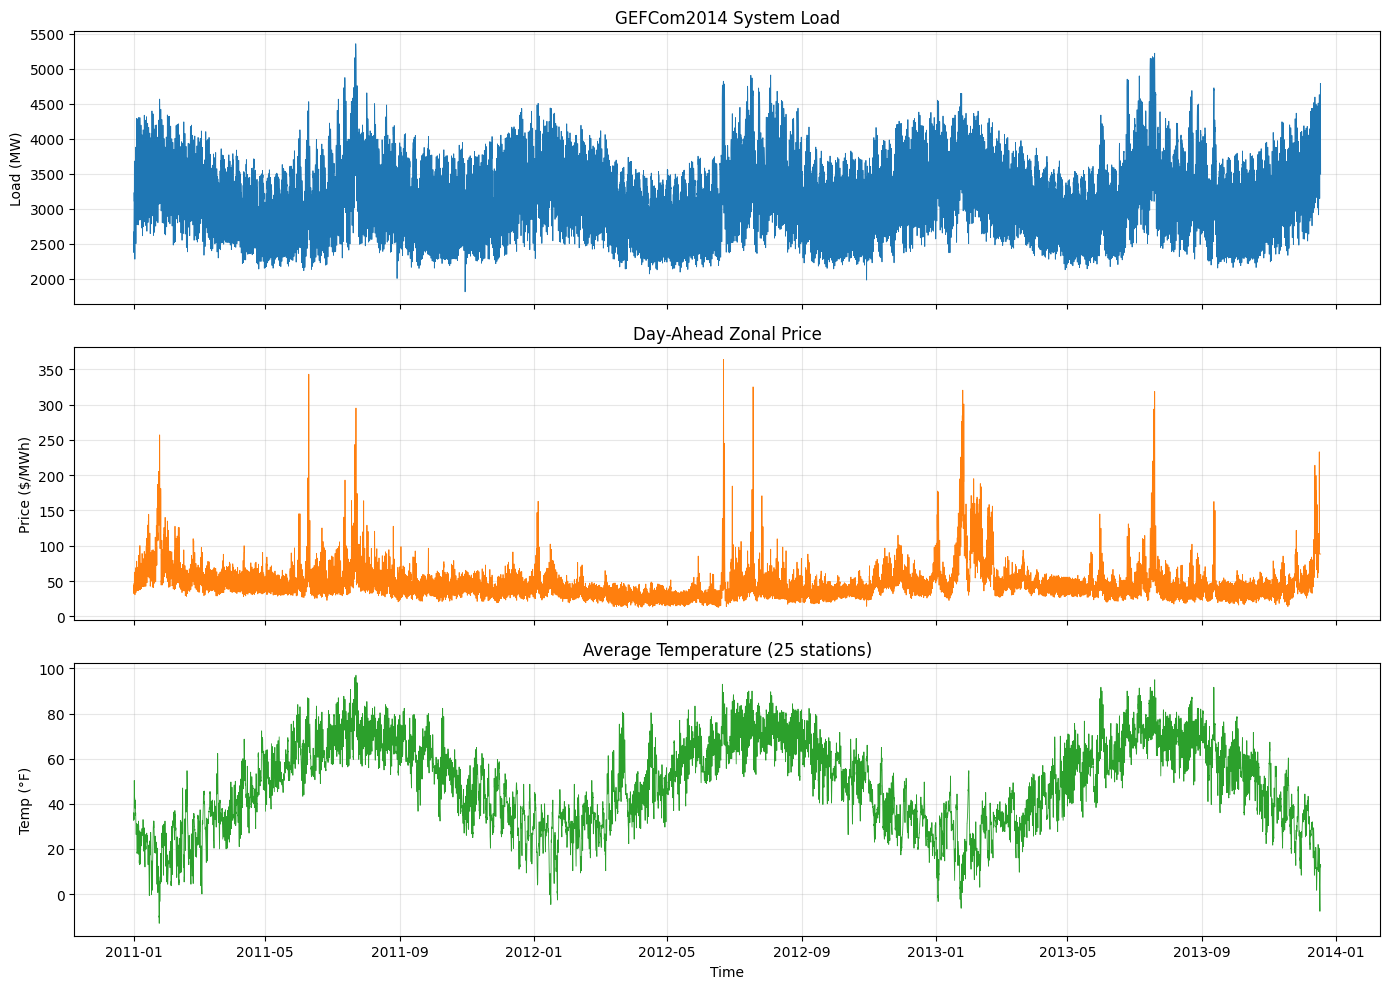

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(merged['timestamp'], merged['load_mw'], color='tab:blue', lw=0.6)
axes[0].set_ylabel('Load (MW)')
axes[0].set_title('GEFCom2014 System Load')
axes[0].grid(True, alpha=0.3)

axes[1].plot(merged['timestamp'], merged['price_da'], color='tab:orange', lw=0.6)
axes[1].set_ylabel('Price ($/MWh)')
axes[1].set_title('Day-Ahead Zonal Price')
axes[1].grid(True, alpha=0.3)

axes[2].plot(merged['timestamp'], merged['temperature'], color='tab:green', lw=0.6)
axes[2].set_ylabel('Temp (°F)')
axes[2].set_title('Average Temperature (25 stations)')
axes[2].set_xlabel('Time')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

> **数据说明**:
> - `load_mw`: 系统总负荷（GEFCom2014-L 各 ZONE 之和）
> - `price_da`: 日前区域电价（GEFCom2014-P 各 ZONE 均值）
> - `temperature`: 25 个气象站温度的平均值（华氏度）
> 
> **注意**: L 赛道和 P 赛道可能来自不同地理区域，中期报告中可写为
> "采用 GEFCom2014 竞赛公开数据集，包含负荷、气象与电价信息"
> 无需强调区域是否完全一致。